In [11]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import gc

transform = transforms.Compose([
    transforms.ToTensor(),  
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)


In [12]:
print(train_loader.dataset.data.shape)

torch.Size([60000, 28, 28])


MODEL

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class mnist(nn.Module):
    def __init__(self):
        super(mnist, self).__init__()
        self.conv1 = nn.Conv2d(1,6, kernel_size=5, stride=1, padding=2)
        self.tanh1 = nn.Tanh()
        self.pool1 = nn.AvgPool2d(kernel_size=2,  stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        self.tang2 = nn.Tanh()
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1)
        self.tanh3 = nn.Tanh()
        self.fc1 = nn.Linear(120, 84)
        self.tanh4 = nn.Tanh()
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(self.tanh1(self.conv1(x)))
        x = self.pool2(self.tang2(self.conv2(x)))
        x = self.tanh3(self.conv3(x))
        x = x.view(-1, 120)  # Flatten the tensor
        x = self.tanh4(self.fc1(x))
        x = self.fc2(x)
        return x

model = mnist()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
gc.collect()

8

In [14]:
for epoch in range(10):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Epoch [{epoch + 1}/10]')
    print("Training loss", (running_loss / total))  
    print("Training accuracy", (correct *100/ total),'%')
    gc.collect()


    model.eval()
    running_loss_eval = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss_eval += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Testing loss", (running_loss / total))
    print("Testing accuracy", (correct*100 / total),'%')

    gc.collect()

Epoch [1/10]
Training loss 0.5205513297319412
Training accuracy 84.26833333333333 %
Testing loss 3.1233079783916473
Testing accuracy 95.33 %
Epoch [2/10]
Training loss 0.12194242251118025
Training accuracy 96.33666666666667 %
Testing loss 0.7316545350670814
Testing accuracy 97.33 %
Epoch [3/10]
Training loss 0.07804413565844297
Training accuracy 97.60333333333334 %
Testing loss 0.46826481395065783
Testing accuracy 97.7 %
Epoch [4/10]
Training loss 0.05908646318092942
Training accuracy 98.19333333333333 %
Testing loss 0.35451877908557655
Testing accuracy 98.38 %
Epoch [5/10]
Training loss 0.048390141498545806
Training accuracy 98.46833333333333 %
Testing loss 0.2903408489912748
Testing accuracy 98.51 %
Epoch [6/10]
Training loss 0.041021034300078946
Training accuracy 98.71666666666667 %
Testing loss 0.2461262058004737
Testing accuracy 98.68 %
Epoch [7/10]
Training loss 0.0355230336751168
Training accuracy 98.87 %
Testing loss 0.21313820205070078
Testing accuracy 98.44 %
Epoch [8/10]
Tra

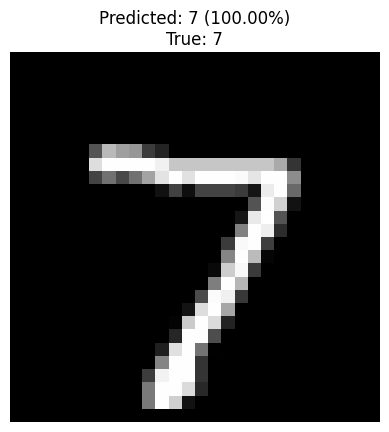

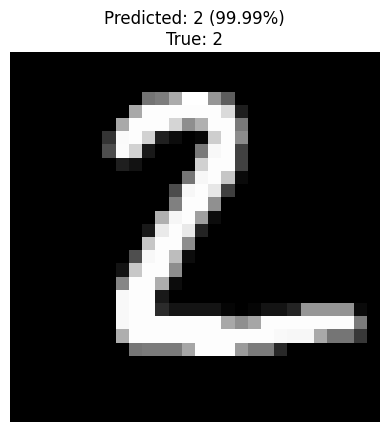

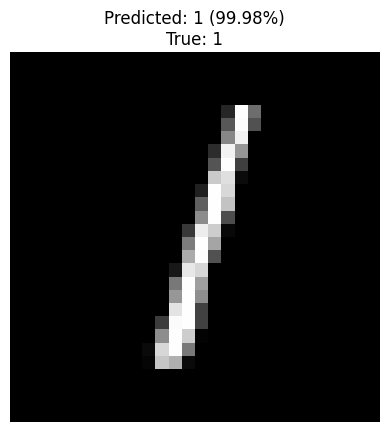

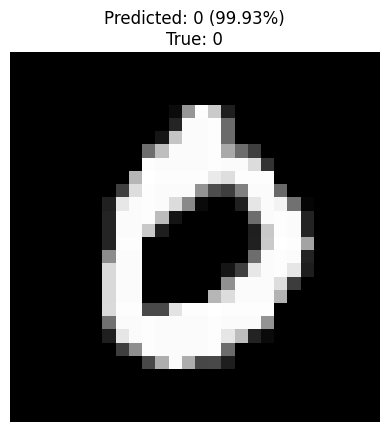

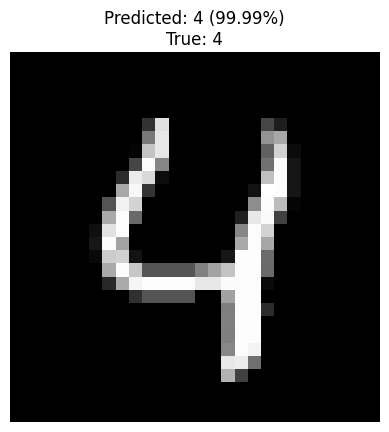

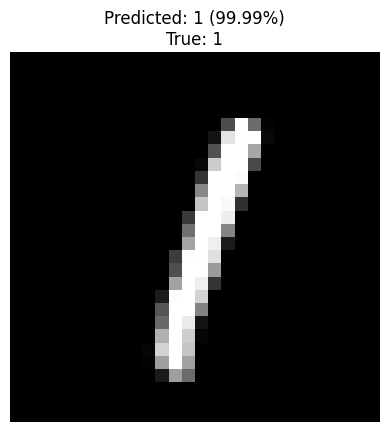

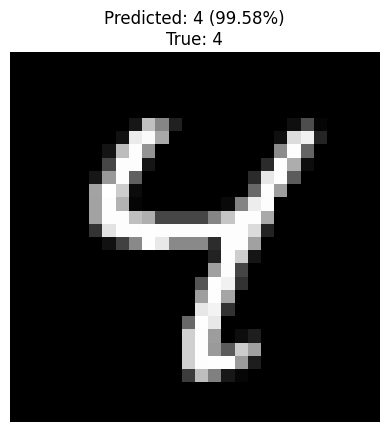

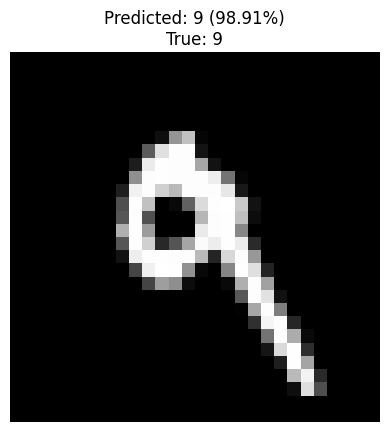

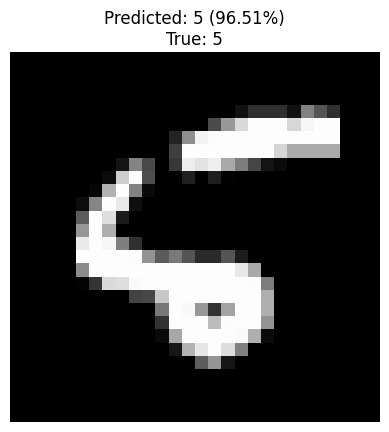

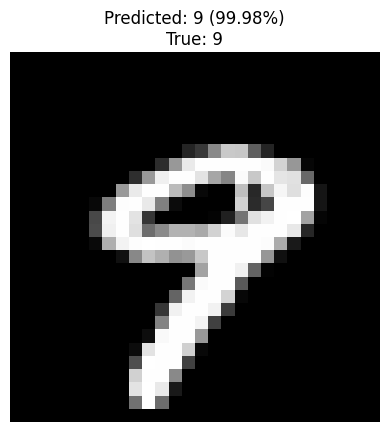

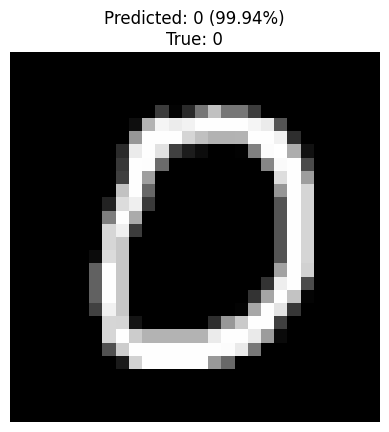

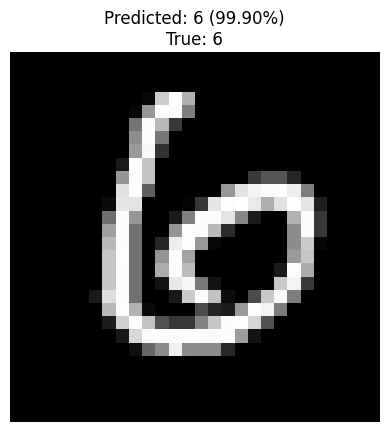

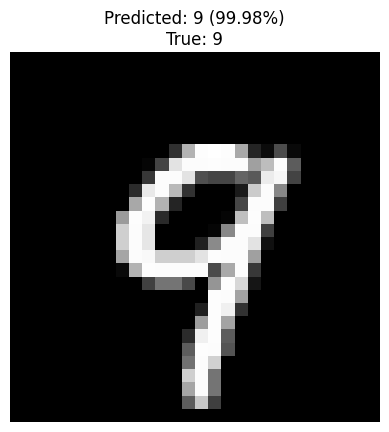

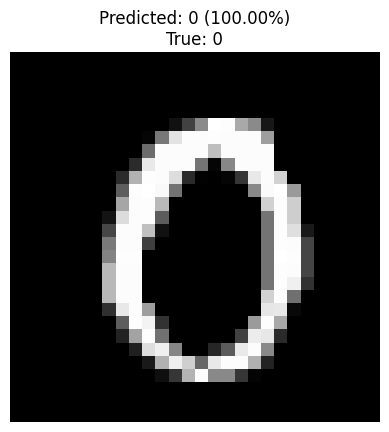

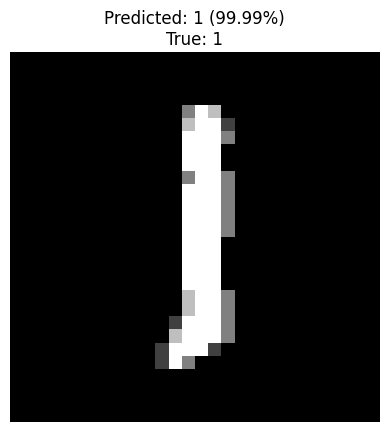

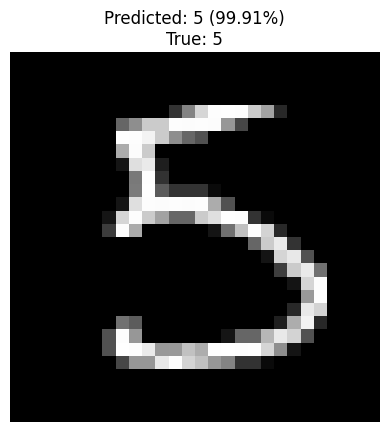

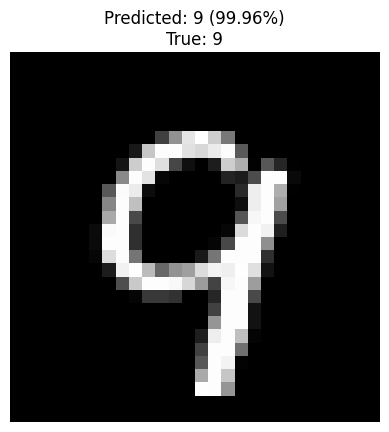

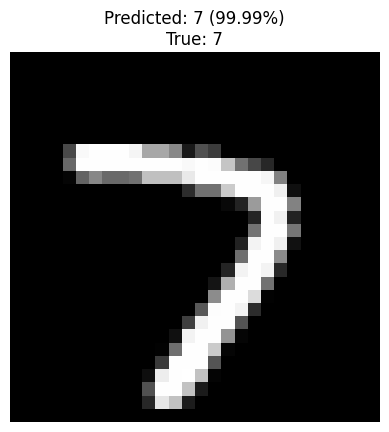

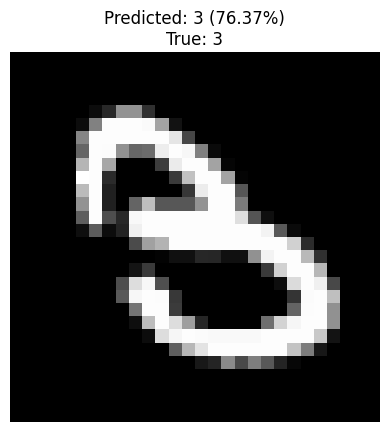

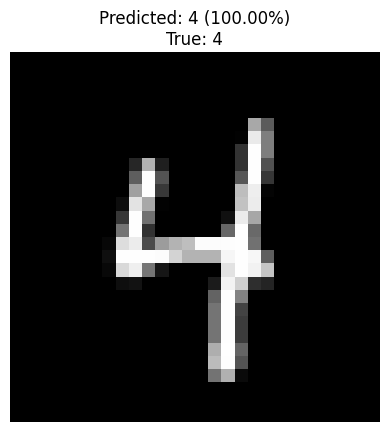

In [16]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

model.eval()
N = 20  
examples_shown = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)  # convert logits to probabilities
        confidences, predictions = torch.max(probs, 1)

        for i in range(inputs.size(0)):
            image = inputs[i].squeeze().numpy()  # remove channel dim
            true_label = labels[i].item()
            pred_label = predictions[i].item()
            confidence = confidences[i].item()

            # Plot the image
            plt.imshow(image, cmap='gray')
            plt.title(f"Predicted: {pred_label} ({confidence*100:.2f}%)\nTrue: {true_label}")
            plt.axis('off')
            plt.show()

            examples_shown += 1
            if examples_shown >= N:
                break
        if examples_shown >= N:
            break
